In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.gridspec as gridspec

# Load clean data
df = pd.read_csv("../data/cleaned/ae_clean.csv", parse_dates=['period'])

print(f"Rows: {len(df)}")
print(f"Trusts: {df['org_name'].nunique()}")
print(f"Date range: {df['period'].min().strftime('%b %Y')} to {df['period'].max().strftime('%b %Y')}")

Importing plotly failed. Interactive plots will not work.


Rows: 4475
Trusts: 203
Date range: Apr 2024 to Mar 2026


In [2]:
# GLOBAL CHART STYLE

NHS_BLUE   = '#185FA5'
NHS_DARK   = '#042C53'
NHS_TEAL   = '#1D9E75'
NHS_CORAL  = '#993C1D'
NHS_AMBER  = '#E8A317'
NHS_LIGHT  = '#E6F1FB'
GRAY_TEXT  = '#5F5E5A'
GRAY_LIGHT = '#F1EFE8'

mpl.rcParams.update({
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : 'white',
    'axes.edgecolor'      : '#D3D1C7',
    'axes.linewidth'      : 0.8,
    'axes.titlesize'      : 14,
    'axes.titleweight'    : 'bold',
    'axes.titlecolor'     : NHS_DARK,
    'axes.labelsize'      : 11,
    'axes.labelcolor'     : GRAY_TEXT,
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'xtick.labelsize'     : 10,
    'ytick.labelsize'     : 10,
    'xtick.color'         : GRAY_TEXT,
    'ytick.color'         : GRAY_TEXT,
    'legend.fontsize'     : 10,
    'legend.framealpha'   : 0.9,
    'legend.edgecolor'    : '#D3D1C7',
    'figure.dpi'          : 120,
    'savefig.dpi'         : 200,
    'savefig.bbox'        : 'tight',
    'savefig.facecolor'   : 'white',
    'font.family'         : 'sans-serif',
    'grid.color'          : '#E8E6DF',
    'grid.linewidth'      : 0.5,
})


In [3]:
# Sum all attendances across all trusts per month
national = (df.groupby('period')['total_attendances']
              .sum()
              .reset_index()
              .sort_values('period'))

national.columns = ['period', 'total_attendances']

print("National monthly A&E attendances:")
print(national.to_string(index=False))

National monthly A&E attendances:
    period  total_attendances
2024-04-01            2163149
2024-05-01            2331010
2024-06-01            2215640
2024-07-01            2251330
2024-08-01            2086225
2024-09-01            2140977
2024-10-01            2280392
2024-11-01            2234578
2024-12-01            2258452
2025-01-01            2133300
2025-02-01            2008463
2025-03-01            2299660
2025-04-01            2209687
2025-05-01            2309298
2025-06-01            2268166
2025-07-01            2320374
2025-08-01            2182723
2025-09-01            2227502
2025-10-01            2314177
2025-11-01            2261926
2025-12-01            2240325
2026-01-01            2235959
2026-02-01            2043572
2026-03-01            2351317


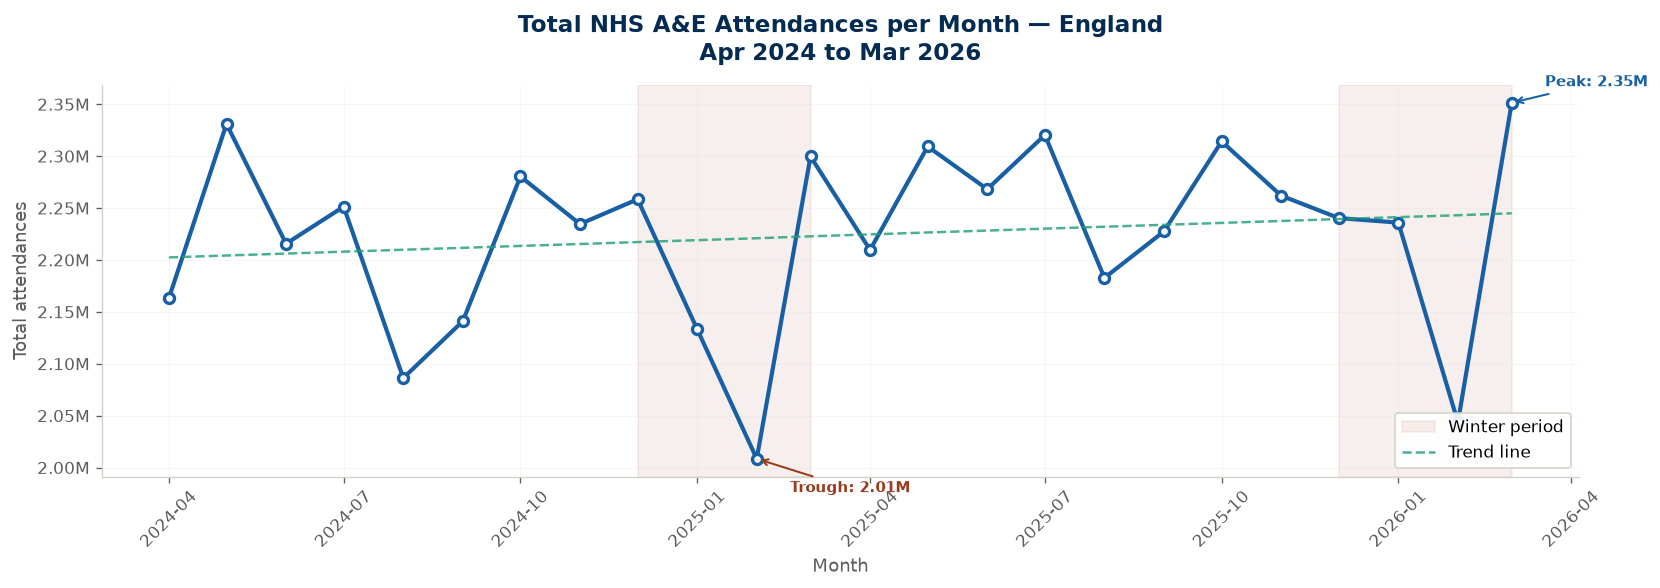

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(national['period'], national['total_attendances'],
        color=NHS_BLUE, linewidth=2.5,
        marker='o', markersize=6,
        markerfacecolor='white', markeredgecolor=NHS_BLUE,
        markeredgewidth=2)

# Shade winter months
for year in [2024, 2025]:
    ax.axvspan(pd.Timestamp(f'{year}-12-01'),
               pd.Timestamp(f'{year+1}-03-01'),
               alpha=0.08, color=NHS_CORAL,
               label='Winter period' if year == 2024 else '')

# Add trend line
from numpy.polynomial import polynomial as P
x_num = np.array(range(len(national)))
coeffs = P.polyfit(x_num, national['total_attendances'], 1)
trend  = P.polyval(x_num, coeffs)
ax.plot(national['period'], trend,
        color=NHS_TEAL, linewidth=1.5,
        linestyle='--', label='Trend line', alpha=0.8)

# Format y axis with commas
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.2f}M'))

ax.set_title('Total NHS A&E Attendances per Month — England\nApr 2024 to Mar 2026',
             pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Total attendances')
ax.grid(True, alpha=0.4)
ax.legend(loc='lower right')
plt.xticks(rotation=45)

# Annotate peak and trough
peak_idx  = national['total_attendances'].idxmax()
trough_idx = national['total_attendances'].idxmin()
ax.annotate(f"Peak: {national.loc[peak_idx,'total_attendances']/1e6:.2f}M",
             xy=(national.loc[peak_idx,'period'],
                 national.loc[peak_idx,'total_attendances']),
             xytext=(20, 10), textcoords='offset points',
             fontsize=9, color=NHS_BLUE, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=NHS_BLUE, lw=1.2))
ax.annotate(f"Trough: {national.loc[trough_idx,'total_attendances']/1e6:.2f}M",
             xy=(national.loc[trough_idx,'period'],
                 national.loc[trough_idx,'total_attendances']),
             xytext=(20, -20), textcoords='offset points',
             fontsize=9, color=NHS_CORAL, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=NHS_CORAL, lw=1.2))

plt.tight_layout()
plt.savefig('../output-files/10_national_attendance_trend.png')
plt.show()

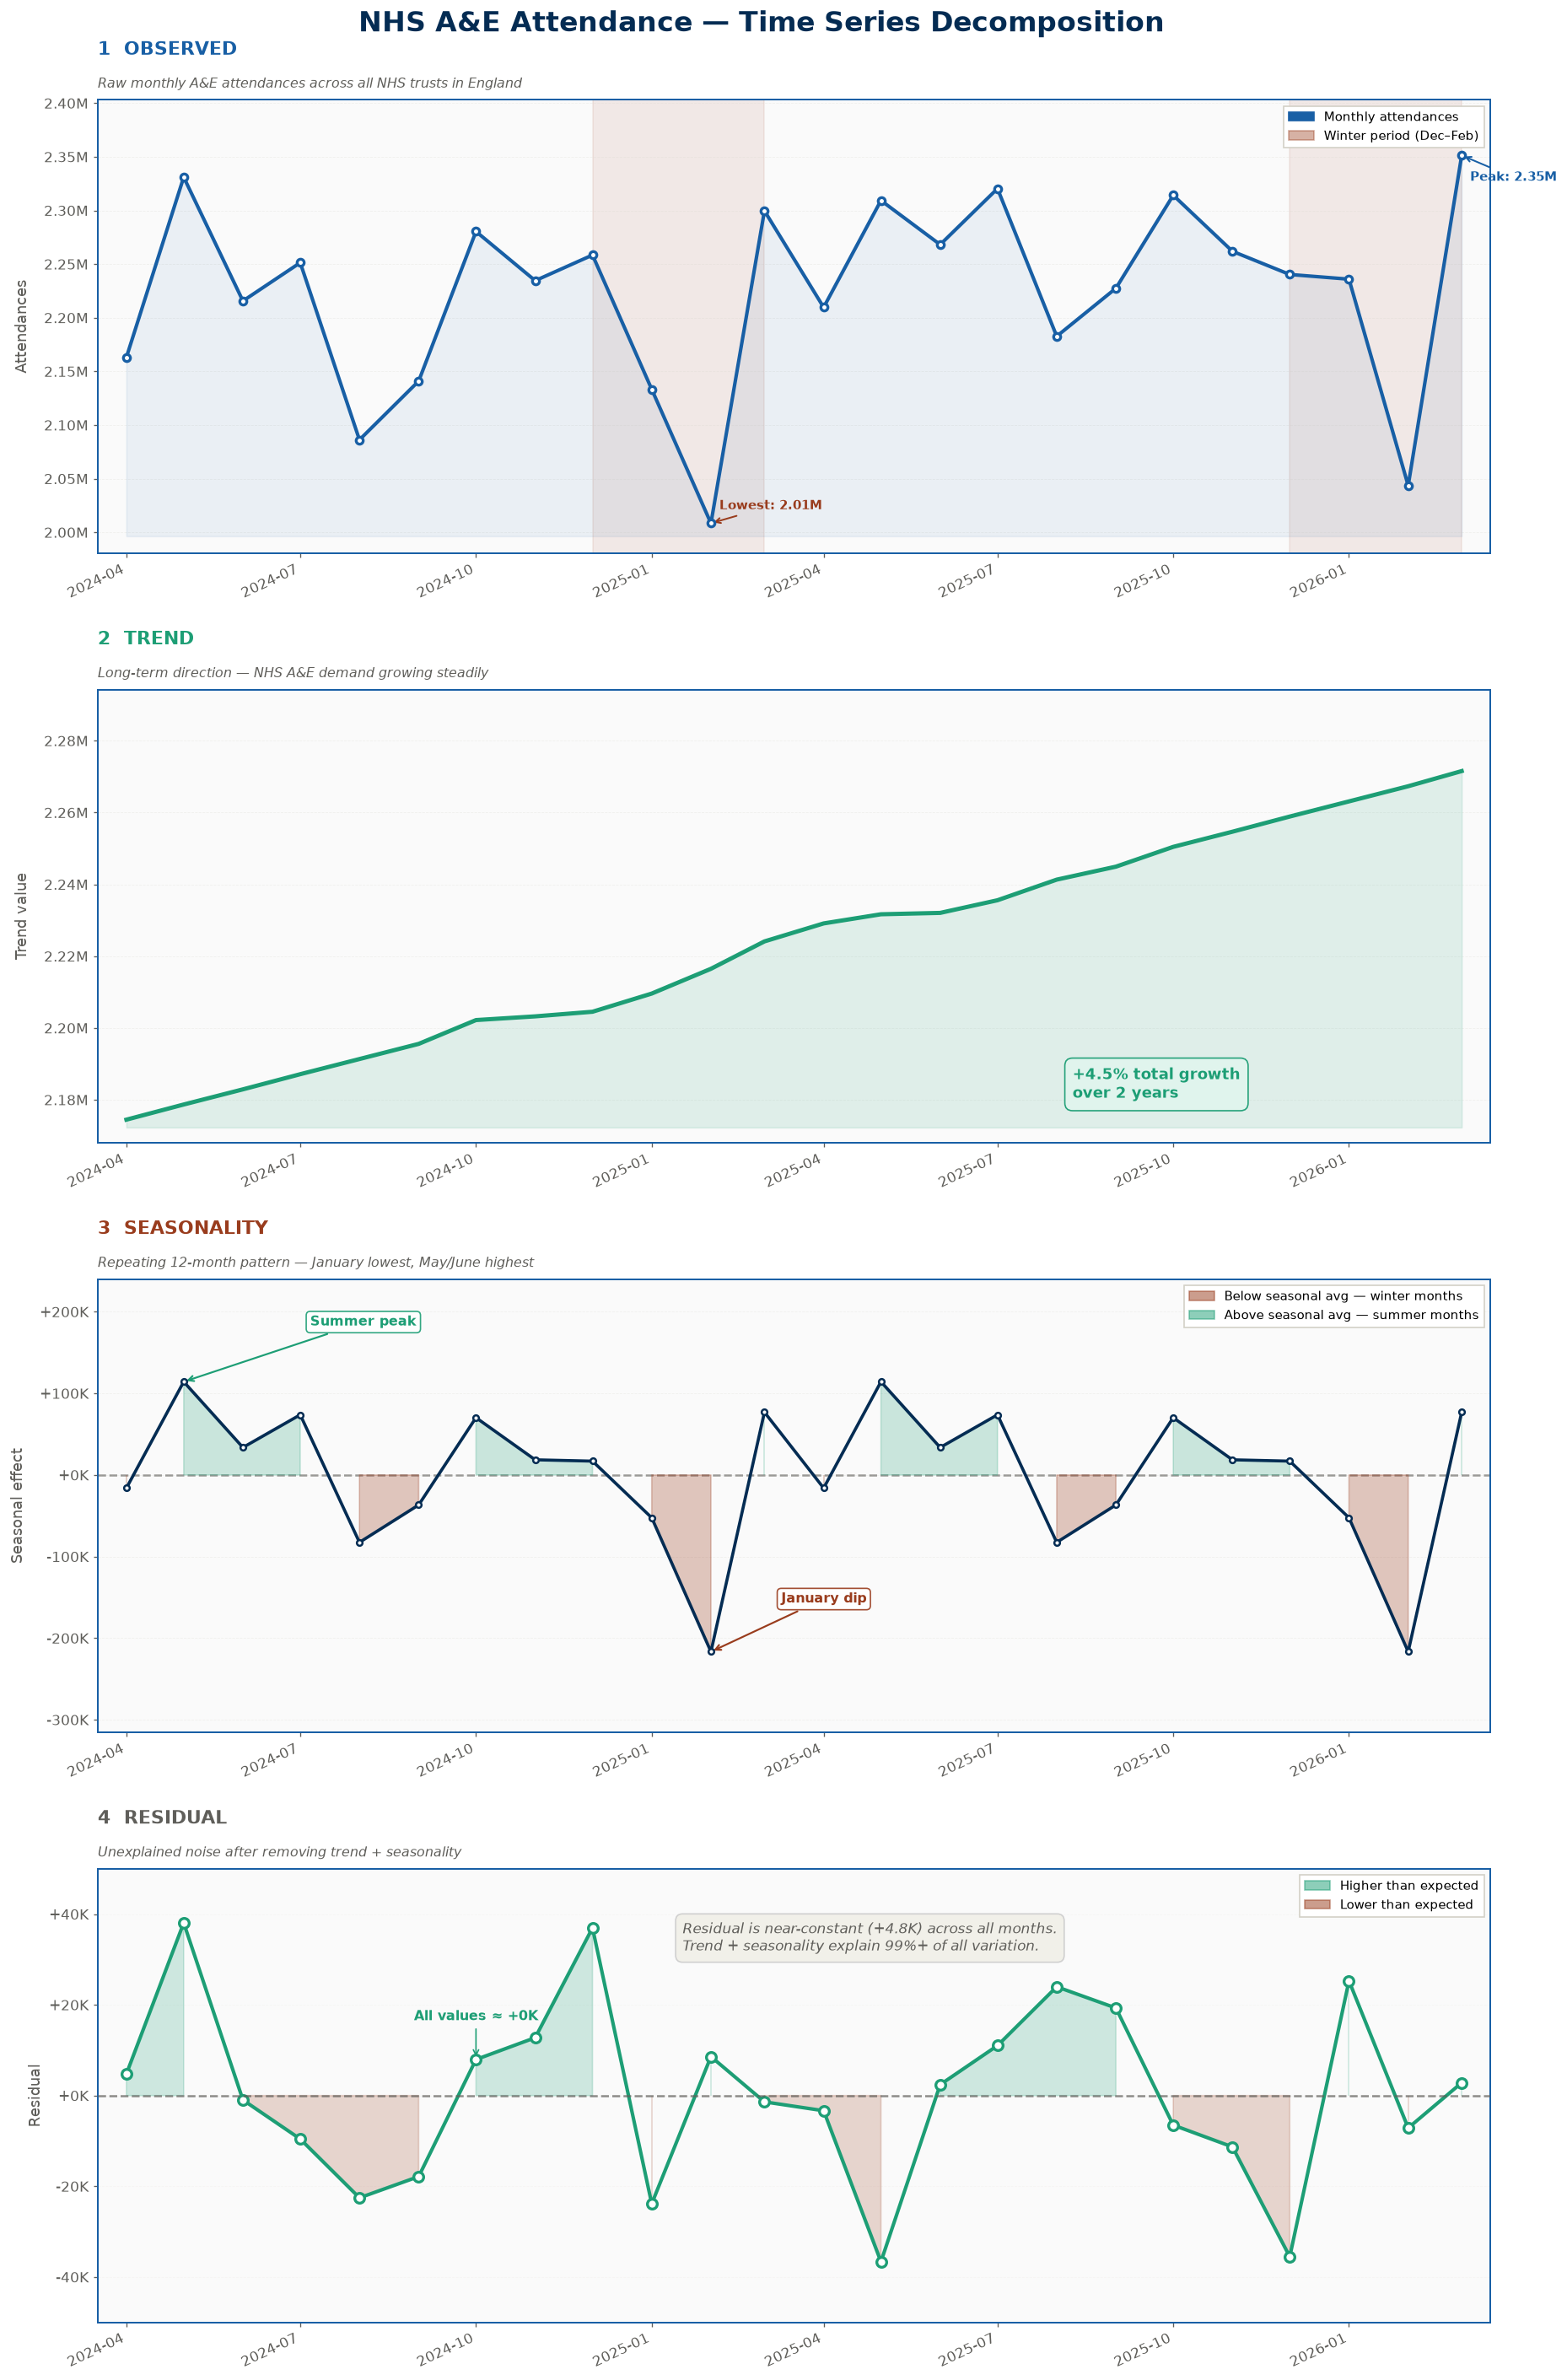

In [5]:
# Decompose into trend + seasonality + residual
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

decomp = seasonal_decompose(
    national.set_index('period')['total_attendances'],
    model='additive',
    period=12,
    extrapolate_trend='freq'
)

obs_vals   = decomp.observed
trend_vals = decomp.trend
seas_vals  = decomp.seasonal
resid_vals = decomp.resid

xmin = obs_vals.index.min()
xmax = obs_vals.index.max()

# Figure-use GridSpec for full control of spacing 
fig = plt.figure(figsize=(16, 24))
fig.patch.set_facecolor('white')

# Each panel gets its own row height
# Row 0,2,4,6 = chart panels
# Row 1,3,5   = spacer rows between panels
gs = gridspec.GridSpec(
    7, 1,
    height_ratios=[4, 1.2, 4, 1.2, 4, 1.2, 4],
    top=0.955, bottom=0.04,
    left=0.09, right=0.95,
    hspace=0.0
)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[4])
ax4 = fig.add_subplot(gs[6])
axes = [ax1, ax2, ax3, ax4]

# Hide spacer rows-they are just empty space
for idx in [1, 3, 5]:
    sp = fig.add_subplot(gs[idx])
    sp.set_visible(False)

# Main title
fig.text(0.5, 0.992,
         'NHS A&E Attendance — Time Series Decomposition',
         fontsize=20, fontweight='bold',
         color=NHS_DARK, ha='center', va='top')
# clean axes styling-helper
def clean_ax(ax, ylabel):
    ax.set_xlim([xmin - pd.Timedelta(days=15),
                 xmax + pd.Timedelta(days=15)])
    ax.spines['top'].set_visible(True)     
    ax.spines['right'].set_visible(True)    
    ax.spines['left'].set_color('#185FA5') 
    ax.spines['bottom'].set_color('#185FA5')
    ax.spines['top'].set_color('#185FA5')
    ax.spines['right'].set_color('#185FA5')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.spines['top'].set_linewidth(1.2)
    ax.spines['right'].set_linewidth(1.2)
    ax.set_facecolor('#FAFAFA')
    ax.tick_params(colors=GRAY_TEXT, labelsize=10, length=3)
    ax.set_ylabel(ylabel, fontsize=11,
                  color=GRAY_TEXT, labelpad=10)
    ax.grid(True, axis='y', alpha=0.25,
            linestyle='--', color='#D3D1C7')
    ax.grid(False, axis='x')
    plt.setp(ax.xaxis.get_majorticklabels(),
             rotation=25, ha='right', fontsize=10)

# Helper-panel header block 
def panel_header(ax, number, title, subtitle, title_color,
                 legend_right=None):
    """
    Title and subtitle sit ABOVE the box.
    Legend sits INSIDE the box at top right.
    """
    # Title-left aligned, above box
    ax.text(0.0, 1.09, f'{number}  {title}',
            transform=ax.transAxes,
            fontsize=13, fontweight='bold',
            color=title_color,
            va='bottom', ha='left')

    # Subtitle-below title, above box
    ax.text(0.0, 1.02, subtitle,
            transform=ax.transAxes,
            fontsize=9.5, color=GRAY_TEXT,
            style='italic',
            va='bottom', ha='left')

    # Legend-INSIDE the box, top right corner
    if legend_right:
        for i, (color, label) in enumerate(legend_right):
            ax.text(0.99, 0.97 - i * 0.09,
                    f'■  {label}',
                    transform=ax.transAxes,
                    fontsize=9, color=color,
                    va='top', ha='right',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor='white',
                              edgecolor='none',
                              alpha=0.8))

# 1-OBSERVED
ax = axes[0]

# Winter shading
for s, e in [('2024-12-01','2025-03-01'),
             ('2025-12-01','2026-03-01')]:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
               alpha=0.09, color=NHS_CORAL, zorder=1)

ax.fill_between(obs_vals.index, obs_vals.values,
                obs_vals.min() * 0.994,
                alpha=0.07, color=NHS_BLUE, zorder=2)

ax.plot(obs_vals.index, obs_vals.values,
        color=NHS_BLUE, linewidth=2.5,
        marker='o', markersize=5,
        markerfacecolor='white',
        markeredgecolor=NHS_BLUE,
        markeredgewidth=2, zorder=4)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.2f}M'))
ax.set_ylim([obs_vals.min() * 0.986,
             obs_vals.max() * 1.022])
clean_ax(ax, 'Attendances')

panel_header(ax,'1', 'OBSERVED',
             'Raw monthly A&E attendances across all NHS trusts in England',
             NHS_BLUE)

ax.legend(handles=[
    mpatches.Patch(color=NHS_BLUE,
                   label='Monthly attendances'),
    mpatches.Patch(color=NHS_CORAL, alpha=0.4,
                   label='Winter period (Dec–Feb)'),
], loc='upper right',
   fontsize=9,
   framealpha=1.0,
   edgecolor='#D3D1C7',
   fancybox=False)
    

# Annotations
pk = obs_vals.idxmax()
lo = obs_vals.idxmin()
ax.annotate(f'Peak: {obs_vals[pk]/1e6:.2f}M',
             xy=(pk, obs_vals[pk]),
             xytext=(6, -18), textcoords='offset points',
             fontsize=9, color=NHS_BLUE, fontweight='bold',
             arrowprops=dict(arrowstyle='->',
                             color=NHS_BLUE, lw=1.2))
ax.annotate(f'Lowest: {obs_vals[lo]/1e6:.2f}M',
             xy=(lo, obs_vals[lo]),
             xytext=(6, 10), textcoords='offset points',
             fontsize=9, color=NHS_CORAL, fontweight='bold',
             arrowprops=dict(arrowstyle='->',
                             color=NHS_CORAL, lw=1.2))


# 2-TREND
ax = axes[1]

ax.plot(trend_vals.index, trend_vals.values,
        color=NHS_TEAL, linewidth=3, zorder=3)
ax.fill_between(trend_vals.index, trend_vals.values,
                trend_vals.min() * 0.999,
                alpha=0.12, color=NHS_TEAL, zorder=2)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.2f}M'))
ax.set_ylim([trend_vals.min() * 0.997,
             trend_vals.max() * 1.010])
clean_ax(ax, 'Trend value')

panel_header(ax,'2', 'TREND',
             'Long-term direction — NHS A&E demand growing steadily',
             NHS_TEAL)

growth = ((trend_vals.iloc[-1] - trend_vals.iloc[0])
          / trend_vals.iloc[0] * 100)
ax.text(0.70, 0.10,
        f'+{growth:.1f}% total growth\nover 2 years',
        transform=ax.transAxes,
        fontsize=11, color=NHS_TEAL, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='#E1F5EE',
                  edgecolor=NHS_TEAL, alpha=0.95))


# 3-SEASONALITY
ax = axes[2]

ax.axhline(y=0, color=GRAY_TEXT, linewidth=1.5,
           linestyle='--', alpha=0.6, zorder=2)

ax.fill_between(seas_vals.index, seas_vals.values, 0,
                where=(seas_vals.values < 0),
                alpha=0.28, color=NHS_CORAL, zorder=3)
ax.fill_between(seas_vals.index, seas_vals.values, 0,
                where=(seas_vals.values > 0),
                alpha=0.22, color=NHS_TEAL, zorder=3)

ax.plot(seas_vals.index, seas_vals.values,
        color=NHS_DARK, linewidth=2.2, zorder=5,
        marker='o', markersize=4,
        markerfacecolor='white',
        markeredgecolor=NHS_DARK,
        markeredgewidth=1.5)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x/1000):+d}K'))

seas_range = seas_vals.max() - seas_vals.min()
ax.set_ylim([seas_vals.min() - seas_range * 0.30,
             seas_vals.max() + seas_range * 0.38])
clean_ax(ax, 'Seasonal effect')

panel_header(ax,'3','SEASONALITY',
             'Repeating 12-month pattern — January lowest, May/June highest',
             NHS_CORAL)

ax.legend(handles=[
    mpatches.Patch(color=NHS_CORAL, alpha=0.5,
                   label='Below seasonal avg — winter months'),
    mpatches.Patch(color=NHS_TEAL, alpha=0.5,
                   label='Above seasonal avg — summer months'),
], loc='upper right',
   fontsize=9,
   framealpha=1.0,
   edgecolor='#D3D1C7',
   fancybox=False)

jan_i = seas_vals.idxmin()
max_i = seas_vals.idxmax()
ax.annotate('January dip',
             xy=(jan_i, seas_vals.min()),
             xytext=(50, 35), textcoords='offset points',
             fontsize=9.5, color=NHS_CORAL, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white',
                       edgecolor=NHS_CORAL, alpha=0.9),
             arrowprops=dict(arrowstyle='->',
                             color=NHS_CORAL, lw=1.3))
ax.annotate('Summer peak',
             xy=(max_i, seas_vals.max()),
             xytext=(90, 40), textcoords='offset points',
             fontsize=9.5, color=NHS_TEAL, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white',
                       edgecolor=NHS_TEAL, alpha=0.9),
             arrowprops=dict(arrowstyle='->',
                             color=NHS_TEAL, lw=1.3))

# 4-RESIDUAL
ax = axes[3]

ax.plot(resid_vals.index, resid_vals.values,
        color=NHS_TEAL, linewidth=2.5,
        marker='o', markersize=7,
        markerfacecolor='white',
        markeredgecolor=NHS_TEAL,
        markeredgewidth=2, zorder=3)

ax.fill_between(resid_vals.index, resid_vals.values, 0,
                where=(resid_vals.values >= 0),
                alpha=0.20, color=NHS_TEAL, zorder=2)
ax.fill_between(resid_vals.index, resid_vals.values, 0,
                where=(resid_vals.values < 0),
                alpha=0.20, color=NHS_CORAL, zorder=2)

ax.axhline(y=0, color=GRAY_TEXT, linewidth=1.5,
           linestyle='--', alpha=0.7, zorder=4)

resid_max = max(abs(resid_vals.values))
ax.set_ylim([-50000, 50000])
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x/1000):+d}K'))
ax.set_xlim([xmin - pd.Timedelta(days=15),
             xmax + pd.Timedelta(days=15)])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D3D1C7')
ax.spines['bottom'].set_color('#D3D1C7')
ax.tick_params(colors=GRAY_TEXT, labelsize=10, length=3)
ax.set_ylabel('Residual', fontsize=11, color=GRAY_TEXT)
ax.grid(True, axis='y', alpha=0.25, linestyle='--')
plt.setp(ax.xaxis.get_majorticklabels(),
         rotation=25, ha='right', fontsize=10)

panel_header(ax,'4', 'RESIDUAL',
             'Unexplained noise after removing trend + seasonality',
             GRAY_TEXT)

ax.legend(handles=[
    mpatches.Patch(color=NHS_TEAL, alpha=0.5,
                   label='Higher than expected'),
    mpatches.Patch(color=NHS_CORAL, alpha=0.5,
                   label='Lower than expected'),
], loc='upper right',
   fontsize=9,
   framealpha=1.0,
   edgecolor='#D3D1C7',
   fancybox=False)

ax.text(0.42, 0.82,
        'Residual is near-constant (+4.8K) across all months.\n'
        'Trend + seasonality explain 99%+ of all variation.',
        transform=ax.transAxes,
        fontsize=10, color=GRAY_TEXT, style='italic',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor=GRAY_LIGHT,
                  edgecolor='#CCCCCC', alpha=0.9))

ax.annotate(f'All values ≈ +{int(resid_vals.mean()/1000):.0f}K',
             xy=(resid_vals.index[6], resid_vals.iloc[6]),
             xytext=(0, 28), textcoords='offset points',
             fontsize=9.5, color=NHS_TEAL, fontweight='bold',
             ha='center',
             arrowprops=dict(arrowstyle='->', color=NHS_TEAL))
# Add background card effect to each panel
for ax in axes:
    ax.set_facecolor('#FAFAFA')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#185FA5')
        spine.set_linewidth(1.2)

plt.savefig('../output-files/11_time_series_decomposition.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


In [6]:
# Augmented Dickey-Fuller test
result = adfuller(national['total_attendances'])

print("=== Stationarity Test (ADF) ===")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value:       {result[1]:.4f}")
print()
if result[1] < 0.05:
    print("Result: STATIONARY ✓")
    print("The series has no unit root-safe to model directly")
else:
    print("Result: NON-STATIONARY")
    print("The series needs differencing before SARIMA")

=== Stationarity Test (ADF) ===
ADF Statistic: -5.0353
p-value:       0.0000

Result: STATIONARY ✓
The series has no unit root-safe to model directly


In [7]:
# Use last 3 months as test set-same logic as Project 1
train = national[national['period'] < '2026-01-01']
test  = national[national['period'] >= '2026-01-01']

print(f"Training months: {len(train)} "
      f"({train['period'].min().strftime('%b %Y')} to "
      f"{train['period'].max().strftime('%b %Y')})")
print(f"Test months:     {len(test)} "
      f"({test['period'].min().strftime('%b %Y')} to "
      f"{test['period'].max().strftime('%b %Y')})")

Training months: 21 (Apr 2024 to Dec 2025)
Test months:     3 (Jan 2026 to Mar 2026)


In [8]:
import pmdarima as pm

# Auto ARIMA finds the best parameters automatically
print("Finding best SARIMA parameters...")

sarima_model = pm.auto_arima(
    train['total_attendances'],
    seasonal=True,
    m=12,                # 12 month seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    information_criterion='aic',
    trace=True           # shows which models it tried
)

print(f"\nBest model found: {sarima_model.order} "
      f"x {sarima_model.seasonal_order}")
print(f"AIC score: {sarima_model.aic():.2f}")

Finding best SARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=546.894, Time=0.57 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=538.161, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=541.782, Time=0.22 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=540.239, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=675.475, Time=0.01 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=540.160, Time=0.04 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=538.119, Time=0.05 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=540.087, Time=0.10 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=539.788, Time=0.09 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=541.744, Time=0.20 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=540.144, Time=0.07 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=542.162, Time=0.13 sec
 ARIMA(0,0,0)(0,0,1)[12]             : AIC=inf, Time=0.11 sec

Best model:  ARIMA(0,0,0)(0,0,1)[12] intercept
Total fit time: 1.795

In [9]:
# Forecast 3 months ahead — Jan, Feb, Mar 2026
n_forecast = len(test)

forecast, conf_int = sarima_model.predict(
    n_periods=n_forecast,
    return_conf_int=True
)

# Build results dataframe
forecast_df = pd.DataFrame({
    'period'   : test['period'].values,
    'actual'   : test['total_attendances'].values,
    'forecast' : forecast,
    'lower'    : conf_int[:, 0],
    'upper'    : conf_int[:, 1]
})

print("=== FORECAST RESULTS ===")
print(forecast_df[['period', 'actual',
                    'forecast', 'lower', 'upper']].to_string(index=False))

=== FORECAST RESULTS ===
    period  actual     forecast        lower        upper
2026-01-01 2235959 2.189791e+06 2.028243e+06 2.351338e+06
2026-02-01 2043572 2.141368e+06 1.979821e+06 2.302915e+06
2026-03-01 2351317 2.254320e+06 2.092772e+06 2.415867e+06


In [10]:
mae  = mean_absolute_error(forecast_df['actual'], forecast_df['forecast'])
rmse = np.sqrt(mean_squared_error(forecast_df['actual'], forecast_df['forecast']))
mape = (abs(forecast_df['actual'] - forecast_df['forecast']) /
        forecast_df['actual'] * 100).mean()

print("=== MODEL EVALUATION ===")
print(f"MAE:  {mae:,.0f} patients")
print(f"RMSE: {rmse:,.0f} patients")
print(f"MAPE: {mape:.1f}%")
print()
print("Interpretation:")
print(f"On average the forecast is off by {mae:,.0f} patients per month")
print(f"That is {mape:.1f}% of actual attendance — "
      f"{'excellent' if mape < 5 else 'good' if mape < 10 else 'acceptable'}")

=== MODEL EVALUATION ===
MAE:  80,320 patients
RMSE: 83,873 patients
MAPE: 3.7%

Interpretation:
On average the forecast is off by 80,320 patients per month
That is 3.7% of actual attendance — excellent


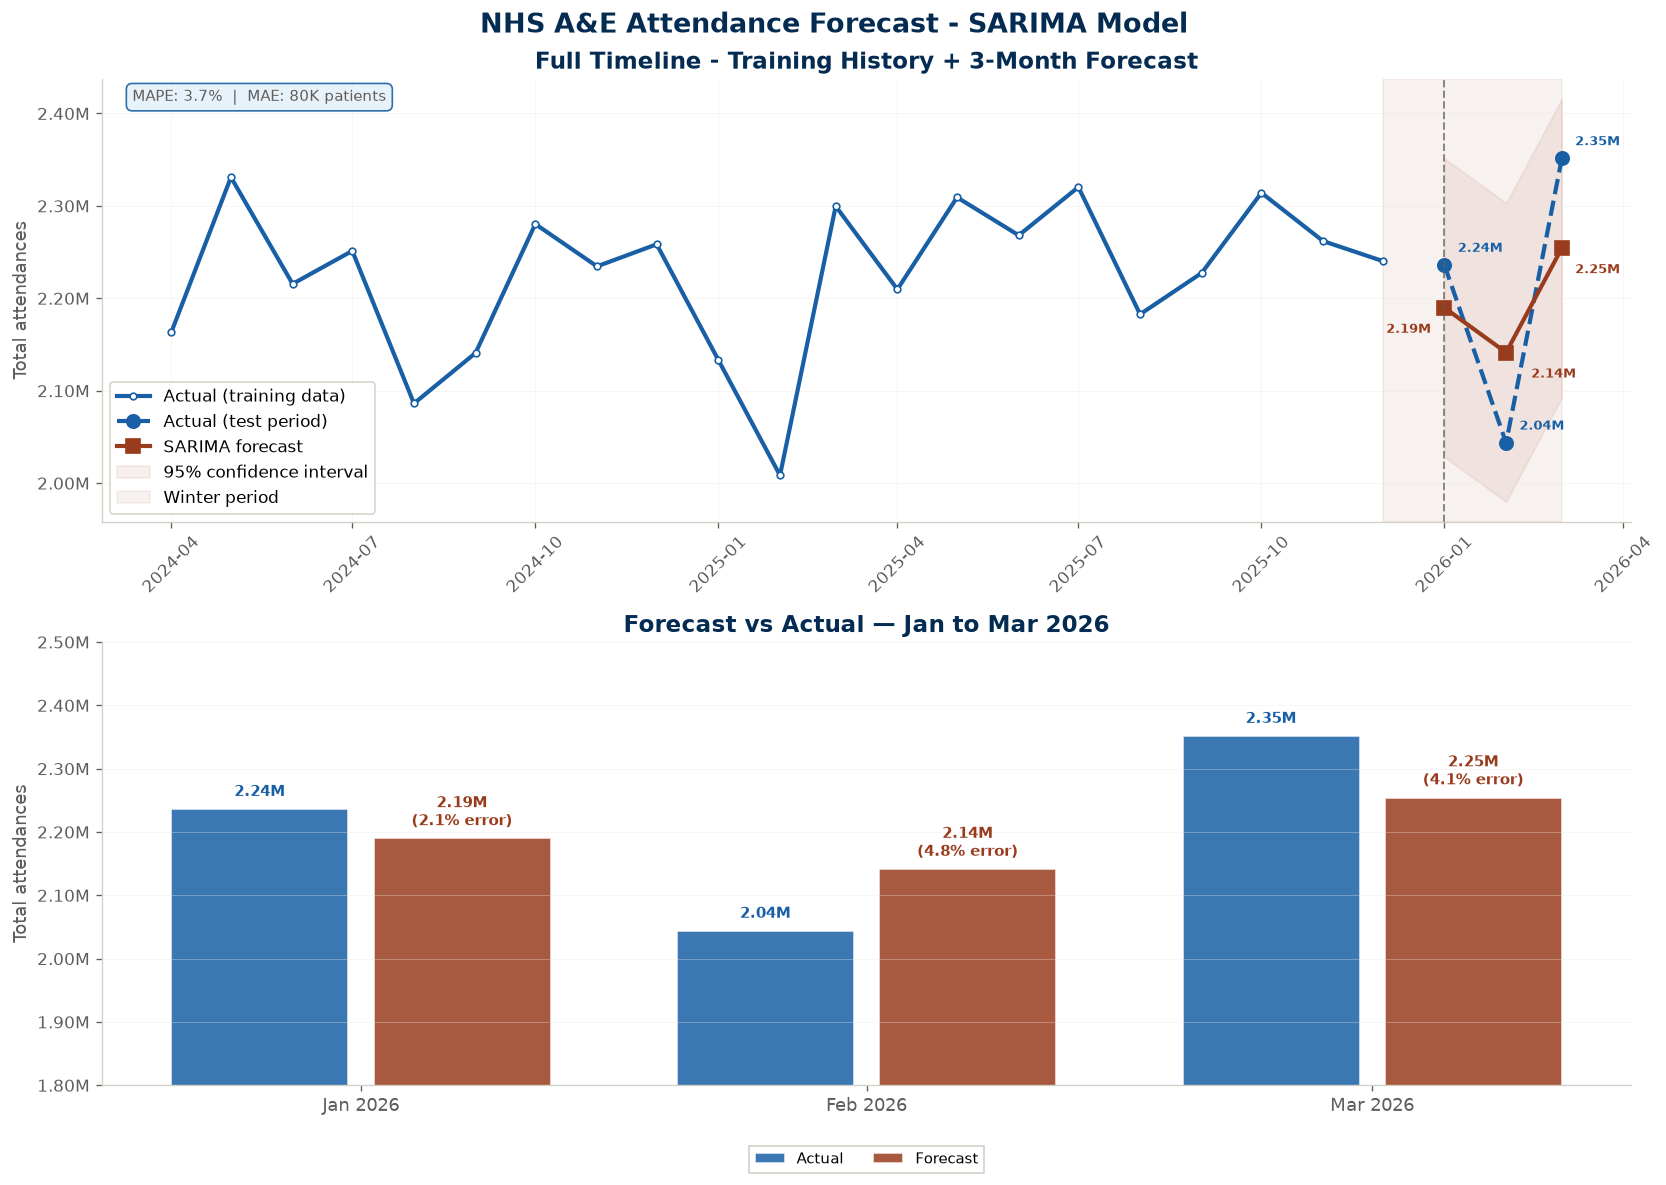


MAE:  80,320 | RMSE: 83,873 | MAPE: 3.7%


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('NHS A&E Attendance Forecast - SARIMA Model',
             fontsize=16, fontweight='bold', color=NHS_DARK)

# TOP PANEL — Full history + forecast 
axes[0].plot(train['period'], train['total_attendances'],
             color=NHS_BLUE, linewidth=2.5,
             marker='o', markersize=4,
             markerfacecolor='white', markeredgecolor=NHS_BLUE,
             label='Actual (training data)')

axes[0].plot(test['period'], test['total_attendances'],
             color=NHS_BLUE, linewidth=2.5,
             linestyle='--', marker='o', markersize=8,
             markerfacecolor=NHS_BLUE,
             label='Actual (test period)')

axes[0].plot(forecast_df['period'], forecast_df['forecast'],
             color=NHS_CORAL, linewidth=2.5,
             marker='s', markersize=8,
             markerfacecolor=NHS_CORAL,
             label='SARIMA forecast')

axes[0].fill_between(forecast_df['period'],
                     forecast_df['lower'],
                     forecast_df['upper'],
                     alpha=0.08, color=NHS_CORAL,
                     label='95% confidence interval')

axes[0].axvline(x=pd.Timestamp('2026-01-01'),
                color=GRAY_TEXT, linestyle='--',
                linewidth=1.2, alpha=0.7)

axes[0].axvspan(pd.Timestamp('2025-12-01'),
                pd.Timestamp('2026-03-01'),
                alpha=0.07, color=NHS_CORAL,
                label='Winter period')

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.2f}M'))
axes[0].set_title('Full Timeline - Training History + 3-Month Forecast')
axes[0].set_ylabel('Total attendances')
axes[0].legend(loc='lower left')
axes[0].grid(True, alpha=0.4)
axes[0].text(0.02, 0.95,
             f'MAPE: {mape:.1f}%  |  MAE: {mae/1000:.0f}K patients',
             transform=axes[0].transAxes,
             fontsize=9, color=GRAY_TEXT,
             bbox=dict(boxstyle='round,pad=0.4',
                       facecolor=NHS_LIGHT,
                       edgecolor=NHS_BLUE, alpha=0.9))
for _, row in test.iterrows():
    axes[0].annotate(f"{row['total_attendances']/1e6:.2f}M",
                     xy=(row['period'], row['total_attendances']),
                     xytext=(8, 8), textcoords='offset points',
                     fontsize=8, color=NHS_BLUE, fontweight='bold')
    
# SARIMA forecast value labels 
offsets = [(-35, -15), (15, -15), (8, -15)]  
for (_, row), (ox, oy) in zip(forecast_df.iterrows(), offsets):
    axes[0].annotate(f"{row['forecast']/1e6:.2f}M",
                     xy=(row['period'], row['forecast']),
                     xytext=(ox, oy), textcoords='offset points',
                     fontsize=8, color=NHS_CORAL, fontweight='bold')   

plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

#  BOTTOM PANEL — Zoom into forecast period 
month_labels = [d.strftime('%b %Y') for d in forecast_df['period']]
x_pos = range(len(forecast_df))

axes[1].bar([p - 0.2 for p in x_pos],
            forecast_df['actual'],
            width=0.35, color=NHS_BLUE,
            label='Actual', alpha=0.85, edgecolor='white')
axes[1].bar([p + 0.2 for p in x_pos],
            forecast_df['forecast'],
            width=0.35, color=NHS_CORAL,
            label='Forecast', alpha=0.85, edgecolor='white')

# Error lines
for i, row in forecast_df.iterrows():
    idx = list(forecast_df.index).index(i)
    error = abs(row['actual'] - row['forecast'])
    pct   = error / row['actual'] * 100

    # Label on actual bar (blue)
    axes[1].annotate(f'{row["actual"]/1e6:.2f}M',
                      xy=(idx - 0.2, row['actual']),
                      xytext=(0, 8), textcoords='offset points',
                      fontsize=9, color=NHS_BLUE,
                      ha='center', fontweight='bold')

    # Label on forecast bar (coral) with error %
    axes[1].annotate(f'{row["forecast"]/1e6:.2f}M\n({pct:.1f}% error)',
                      xy=(idx + 0.2, row['forecast']),
                      xytext=(0, 8), textcoords='offset points',
                      fontsize=9, color=NHS_CORAL,
                      ha='center', fontweight='bold')
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(month_labels, fontsize=11)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.2f}M'))
axes[1].set_title('Forecast vs Actual — Jan to Mar 2026')
axes[1].set_ylabel('Total attendances')
axes[1].set_ylim([1.8e6, 2.5e6])
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.2f}M'))
axes[1].legend(loc='upper center',
               bbox_to_anchor=(0.5, -0.12),
               ncol=2,
               fontsize=9,
               framealpha=1.0,
               edgecolor='#D3D1C7',
               fancybox=False)
axes[1].grid(True, axis='y', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.subplots_adjust(bottom=0.12)
plt.tight_layout()
plt.savefig('../output-files/12_sarima_forecast.png')
plt.show()

print(f"\nMAE:  {mae:,.0f} | RMSE: {rmse:,.0f} | MAPE: {mape:.1f}%")